In [474]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize




from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ian\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ian\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ian\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [398]:
df = pd.read_csv("judge-1377884607_tweet_product_company.csv",encoding='ISO-8859-1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [399]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [400]:
df.shape


(9093, 3)

In [401]:
df = df.applymap(lambda x: str(x) if isinstance(x, list) else x)
df.drop_duplicates(inplace=True)

print("Duplicates dropped. New shape:", df.shape)


Duplicates dropped. New shape: (9071, 3)


In [402]:
df = df.rename(columns={'emotion_in_tweet_is_directed_at': 'receiver_end'})

In [403]:
#What are value counts of 'receiver_end'column
df['receiver_end'].value_counts()

iPad                               945
Apple                              659
iPad or iPhone App                 469
Google                             428
iPhone                             296
Other Google product or service    293
Android App                         80
Android                             77
Other Apple product or service      35
Name: receiver_end, dtype: int64

In [404]:
# Preprocess tweet text for NLP analysis:
# Lowercases all words
# Removes links, mentions, hashtags, punctuation (but strips out numbers too)
# Strips excess whitespace
# Filters out common stopwords
# Outputs cleaned tweet string
# Regex pattern to match emojis


def clean_tweet(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # Emoticons
        "\U0001F300-\U0001F5FF"  # Symbols & pictographs
        "\U0001F680-\U0001F6FF"  # Transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # Flags
        "\U00002702-\U000027B0"  # Dingbats
        "\U000024C2-\U0001F251"  # Enclosed characters
        "]+",
        flags=re.UNICODE
    )
    
    text = str(text).lower()
    text = emoji_pattern.sub('', text)  # Remove emojis
    text = re.sub(r"http\S+|@\S+|#\S+|[^a-zA-Z\s]", "", text)  # Remove URLs, mentions, hashtags, non-alpha
    text = re.sub(r"\s+", " ", text).strip()
    stop_words = set(stopwords.words('english'))
    return " ".join([word for word in text.split() if word not in stop_words])





In [405]:
# Apply text cleaning to each tweet and store in new column
df['clean_tweet'] = df['tweet_text'].apply(clean_tweet)
df[['tweet_text', 'clean_tweet']].head()

,tweet_text,clean_tweet
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hrs tweeting dead need upgrade plugin...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,wait also sale
3,@sxsw I hope this year's festival isn't as cra...,hope years festival isnt crashy years iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...


In [406]:
# Frequent words across tweets

from collections import Counter
top_words = Counter(" ".join(df['clean_tweet']).split()).most_common(20)
print(top_words)




[('link', 4268), ('rt', 2945), ('ipad', 2307), ('google', 2010), ('apple', 1735), ('store', 1464), ('iphone', 1249), ('new', 1081), ('austin', 840), ('app', 788), ('amp', 717), ('launch', 636), ('social', 616), ('popup', 597), ('today', 556), ('circles', 522), ('sxsw', 489), ('network', 455), ('via', 435), ('android', 434)]


In [407]:
df["is_there_an_emotion_directed_at_a_brand_or_product"].unique()

array(['Negative emotion', 'Positive emotion',
       'No emotion toward brand or product', "I can't tell"], dtype=object)

In [ ]:
# Define a mapping dictionary with simpler emotion labels and emojis
emotion_map = {
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    'No emotion toward brand or product': 'Neutral',
    "I can't tell": 'Unknown '
}

# Apply the mapping to create a cleaned emotion column
df['emotion_cleaned'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].map(emotion_map)

# Display the cleaned emotion column
df['emotion_cleaned'].head()


0    Negative
1    Positive
2    Positive
3    Negative
4    Positive
Name: emotion_cleaned, dtype: object

In [456]:
# Preview the first few rows of cleaned tweets alongside their corresponding emotion labels

df[['clean_tweet', 'emotion_cleaned']].head()



,clean_tweet,emotion_cleaned
0,g iphone hrs tweeting dead need upgrade plugin...,Negative
1,know awesome ipadiphone app youll likely appre...,Positive
2,wait also sale,Positive
3,hope years festival isnt crashy years iphone app,Negative
4,great stuff fri marissa mayer google tim oreil...,Positive


### Tokenization

In [410]:
# Apply word_tokenize to each cleaned tweet

df['tokens'] = df['clean_tweet'].apply(word_tokenize)

df[['clean_tweet', 'tokens']].head()



,clean_tweet,tokens
0,g iphone hrs tweeting dead need upgrade plugin...,"[g, iphone, hrs, tweeting, dead, need, upgrade..."
1,know awesome ipadiphone app youll likely appre...,"[know, awesome, ipadiphone, app, youll, likely..."
2,wait also sale,"[wait, also, sale]"
3,hope years festival isnt crashy years iphone app,"[hope, years, festival, isnt, crashy, years, i..."
4,great stuff fri marissa mayer google tim oreil...,"[great, stuff, fri, marissa, mayer, google, ti..."


### Lemmatization

In [411]:
lemmatizer = WordNetLemmatizer()

df['lemmatized_tweet'] = df['clean_tweet'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
df['lemmatized_tweet']


0       g iphone hr tweeting dead need upgrade plugin ...
1       know awesome ipadiphone app youll likely appre...
2                                          wait also sale
3          hope year festival isnt crashy year iphone app
4       great stuff fri marissa mayer google tim oreil...
                              ...                        
9088                                 ipad everywhere link
9089    wave buzz rt interrupt regularly scheduled gee...
9090    google zeiger physician never reported potenti...
9091    verizon iphone customer complained time fell b...
9092                    rt google test checkin offer link
Name: lemmatized_tweet, Length: 9071, dtype: object

In [412]:
df[['clean_tweet', 'lemmatized_tweet']].head()


,clean_tweet,lemmatized_tweet
0,g iphone hrs tweeting dead need upgrade plugin...,g iphone hr tweeting dead need upgrade plugin ...
1,know awesome ipadiphone app youll likely appre...,know awesome ipadiphone app youll likely appre...
2,wait also sale,wait also sale
3,hope years festival isnt crashy years iphone app,hope year festival isnt crashy year iphone app
4,great stuff fri marissa mayer google tim oreil...,great stuff fri marissa mayer google tim oreil...


In [413]:
#Combine Regular Columns into One DataFrame

df_features = df[['tweet_text','clean_tweet', 'emotion_cleaned', 'tokens', 'lemmatized_tweet','receiver_end']]
df_features.head()

,tweet_text,clean_tweet,emotion_cleaned,tokens,lemmatized_tweet,receiver_end
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hrs tweeting dead need upgrade plugin...,Negative,"[g, iphone, hrs, tweeting, dead, need, upgrade...",g iphone hr tweeting dead need upgrade plugin ...,iPhone
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...,Positive,"[know, awesome, ipadiphone, app, youll, likely...",know awesome ipadiphone app youll likely appre...,iPad or iPhone App
2,@swonderlin Can not wait for #iPad 2 also. The...,wait also sale,Positive,"[wait, also, sale]",wait also sale,iPad
3,@sxsw I hope this year's festival isn't as cra...,hope years festival isnt crashy years iphone app,Negative,"[hope, years, festival, isnt, crashy, years, i...",hope year festival isnt crashy year iphone app,iPad or iPhone App
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...,Positive,"[great, stuff, fri, marissa, mayer, google, ti...",great stuff fri marissa mayer google tim oreil...,Google


### Vectorize

In [414]:


# Initialize the vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform your lemmatized tweets into a sparse matrix
X = vectorizer.fit_transform(df['lemmatized_tweet'])




In [415]:
# checking the distribution of emotions
percentage = df['emotion_cleaned'].value_counts(normalize=True)
print(percentage * 100)

Neutral     59.265792
Positive    32.741704
Negative     6.272737
Unknown      1.719766
Name: emotion_cleaned, dtype: float64


In [416]:
df['emotion_cleaned'].value_counts()



Neutral     5376
Positive    2970
Negative     569
Unknown      156
Name: emotion_cleaned, dtype: int64

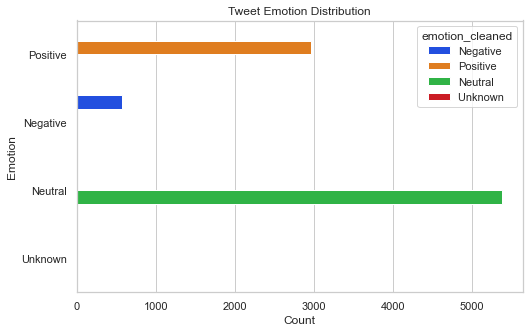

In [417]:
sns.set_theme(style="whitegrid")

# Initialize the plot canvas
plt.figure(figsize=(8,5))

# Create the bar plot (without the invalid legend argument)
order = ['Positive', 'Negative', 'Neutral', 'Unknown']
sns.countplot(data=df_features, y='emotion_cleaned', hue='emotion_cleaned', palette='bright', order=order)


# Set the title and axis labels
plt.title("Tweet Emotion Distribution")
plt.xlabel("Count")
plt.ylabel("Emotion")

# Show the plot
plt.show()




In [418]:
# Count combinations of recipient and emotion
df.groupby('receiver_end')['emotion_cleaned'].value_counts().unstack().fillna(0)
df['receiver_end'] = df['receiver_end'].fillna('Unknown')





In [419]:
df['receiver_end'].unique()

array(['iPhone', 'iPad or iPhone App', 'iPad', 'Google', 'Unknown',
       'Android', 'Apple', 'Android App',
       'Other Google product or service',
       'Other Apple product or service'], dtype=object)

In [420]:
# Replace app-specific labels with their broader categories
df['receiver_end'] = df['receiver_end'].replace({
    'iPad or iPhone App': 'Apple',
    'Other Apple product or service': 'Apple',
    'Other Google product or service': 'Google',
    'Android App': 'Android',
    'iPhone': 'Apple',
    'iPad': 'Apple'
})

In [421]:

df_features['receiver_end'] = df['receiver_end']
df_features['receiver_end']


0         Apple
1         Apple
2         Apple
3         Apple
4        Google
         ...   
9088      Apple
9089    Unknown
9090    Unknown
9091    Unknown
9092    Unknown
Name: receiver_end, Length: 9071, dtype: object

In [422]:
df["receiver_end"].count()

9071

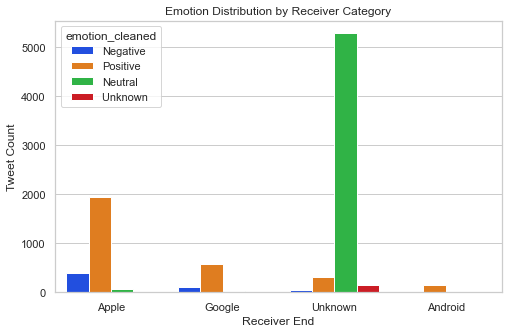

In [423]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='receiver_end', hue='emotion_cleaned', palette='bright')
plt.title("Emotion Distribution by Receiver Category")
plt.xlabel("Receiver End")
plt.ylabel("Tweet Count")
plt.show()


This plots emotion types across brands—perfect for spotting trends like “Apple gets more positivity” or “Android has mixed reactions.

In [424]:
# Create summary table: emotion count per receiver group
emotion_counts = df.groupby('receiver_end')['emotion_cleaned'].value_counts().unstack().fillna(0)

# Reset index to prepare for merge
 
emotion_counts = emotion_counts.reset_index()
emotion_counts



emotion_cleaned,receiver_end,Negative,Neutral,Positive,Unknown
0,Android,16.0,2.0,139.0,0.0
1,Apple,387.0,65.0,1945.0,7.0
2,Google,115.0,24.0,580.0,2.0
3,Unknown,51.0,5285.0,306.0,147.0


In [425]:
print("Columns in emotion_counts:", emotion_counts.columns.tolist())




Columns in emotion_counts: ['receiver_end', 'Negative', 'Neutral', 'Positive', 'Unknown ']


In [426]:
emotion_counts.columns = emotion_counts.columns.str.strip()

#  Reallocate 'Unknown' values to 'Neutral'
if 'Unknown' in emotion_counts.columns and 'Neutral' in emotion_counts.columns:
    emotion_counts['Neutral'] += emotion_counts['Unknown']
    emotion_counts.drop(columns=['Unknown'], inplace=True)
    print(" 'Unknown' merged into 'Neutral'. Columns now:", emotion_counts.columns.tolist())
else:
    print(" 'Unknown' column not found. Check column names below:")
    print(emotion_counts.columns.tolist())



 'Unknown' merged into 'Neutral'. Columns now: ['receiver_end', 'Negative', 'Neutral', 'Positive']


In [427]:
if 'Unknown' in emotion_counts.columns:
    emotion_counts.drop(columns=['Unknown'], inplace=True)
    print("'Unknown' column dropped.")
else:
    print("'Unknown' column already gone. You're working with:", emotion_counts.columns.tolist())



'Unknown' column already gone. You're working with: ['receiver_end', 'Negative', 'Neutral', 'Positive']


In [428]:
df_features = df_features.merge(emotion_counts, on='receiver_end', how='left')

In [429]:
emotion_cols = ['Positive', 'Negative', 'Neutral']
valid_cols = [col for col in emotion_cols if col in df_features.columns]
df_features[valid_cols] = df_features[valid_cols].fillna(0)


In [430]:
for col in emotion_cols:
    if col not in df_features.columns:
        df_features[col] = 0  

df_features[emotion_cols] = df_features[emotion_cols].fillna(0)


In [431]:
df_features[['receiver_end'] + emotion_cols].head()



,receiver_end,Positive,Negative,Neutral
0,Apple,1945.0,387.0,72.0
1,Apple,1945.0,387.0,72.0
2,Apple,1945.0,387.0,72.0
3,Apple,1945.0,387.0,72.0
4,Google,580.0,115.0,26.0


In [432]:
final_df = df_features[[
    'tweet_text',
    'clean_tweet',
    'tokens',
    'lemmatized_tweet',
    'receiver_end'
] + emotion_cols]



In [433]:
final_df = final_df.rename(columns={
    'tweet_text': 'Raw_Tweet',
    'clean_text': 'Clean_Tweet',
    'tokens': 'Tokens',
    'lemmatized_tweet': 'Lemmas',
    'receiver_end': 'Recipient'
})
final_df.head()


,Raw_Tweet,clean_tweet,Tokens,Lemmas,Recipient,Positive,Negative,Neutral
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hrs tweeting dead need upgrade plugin...,"[g, iphone, hrs, tweeting, dead, need, upgrade...",g iphone hr tweeting dead need upgrade plugin ...,Apple,1945.0,387.0,72.0
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...,"[know, awesome, ipadiphone, app, youll, likely...",know awesome ipadiphone app youll likely appre...,Apple,1945.0,387.0,72.0
2,@swonderlin Can not wait for #iPad 2 also. The...,wait also sale,"[wait, also, sale]",wait also sale,Apple,1945.0,387.0,72.0
3,@sxsw I hope this year's festival isn't as cra...,hope years festival isnt crashy years iphone app,"[hope, years, festival, isnt, crashy, years, i...",hope year festival isnt crashy year iphone app,Apple,1945.0,387.0,72.0
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...,"[great, stuff, fri, marissa, mayer, google, ti...",great stuff fri marissa mayer google tim oreil...,Google,580.0,115.0,26.0


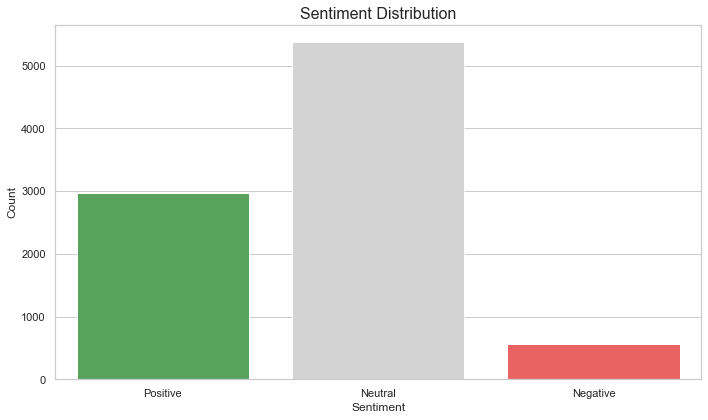

In [460]:
# Absolute count plot for Positive, Neutral, Negative
plt.figure(figsize=(10, 6))
sns.countplot(x='emotion_cleaned', data=final_df, 
              order=['Positive', 'Neutral', 'Negative'],
              palette={'Positive': '#4caf50', 'Neutral': '#d3d3d3', 'Negative': '#ff4d4f'})
plt.title('Sentiment Distribution', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

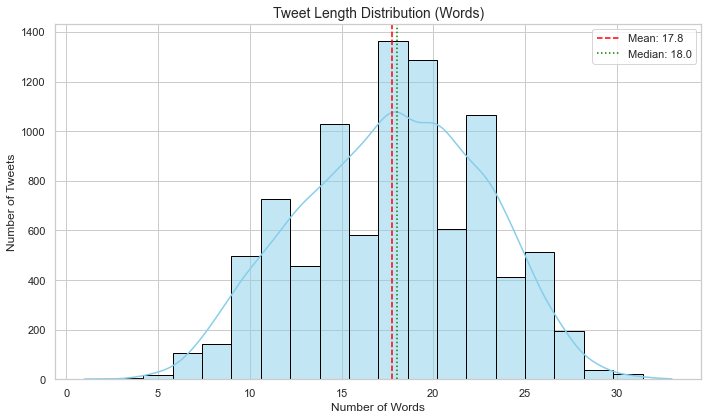

In [461]:

data = enrich_tweets(df, text_col='tweet_text')

def enrich_tweets(df, text_col='tweet_text'):
    df = df.copy()
    df[text_col] = df[text_col].astype(str)
    df['char_count'] = df[text_col].apply(len)
    df['word_count'] = df[text_col].apply(lambda x: len(x.split()))
    df['sentence_count'] = df[text_col].apply(lambda x: len(nltk.sent_tokenize(x)))
    df['avg_word_length'] = df[text_col].apply(
        lambda x: sum(len(word) for word in x.split()) / max(1, len(x.split()))
    )
    df['tweet_length'] = df['word_count']  # Optional alias
    return df

# Apply enrichment
data = enrich_tweets(data, text_col='tweet_text')

# Plot distribution with annotations
plt.figure(figsize=(10, 6))
sns.histplot(data['tweet_length'], bins=20, kde=True, color='skyblue', edgecolor='black')

mean_length = data['tweet_length'].mean()
median_length = data['tweet_length'].median()
plt.axvline(mean_length, color='red', linestyle='--', label=f'Mean: {mean_length:.1f}')
plt.axvline(median_length, color='green', linestyle=':', label=f'Median: {median_length:.1f}')
plt.legend()

plt.title('Tweet Length Distribution (Words)', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.tight_layout()
plt.show()


In [475]:
# Filter out 'Unknown' for modeling
model_df = final_df[final_df['emotion_cleaned'].isin(['Positive', 'Neutral', 'Negative'])]

# Define features and target
X = model_df['Clean_Tweet']  # Or use 'Lemmas' if preferred
y = model_df['emotion_cleaned']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [476]:
# Define pipelines
pipelines = {
    'Logistic Regression (Count)': Pipeline([
        ('vectorizer', CountVectorizer()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
    'Logistic Regression (TF-IDF)': Pipeline([
        ('vectorizer', TfidfVectorizer()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
    'Naive Bayes (Count)': Pipeline([
        ('vectorizer', CountVectorizer()),
        ('classifier', MultinomialNB())
        ]),
    'Naive Bayes (TF-IDF)': Pipeline([
        ('vectorizer', TfidfVectorizer()),
        ('classifier', MultinomialNB())
    ]),
    'Random Forest (Count)': Pipeline([
        ('vectorizer', CountVectorizer()),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'Random Forest (TF-IDF)': Pipeline([
        ('vectorizer', TfidfVectorizer()),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
}

In [477]:
# Parameter grids for GridSearchCV
param_grids = {
    'Logistic Regression (Count)': {
        'vectorizer__max_features': [1000, 2000],
        'classifier__C': [0.1, 1.0]
    },
    'Logistic Regression (TF-IDF)': {
        'vectorizer__max_features': [1000, 2000],
        'classifier__C': [0.1, 1.0]
    },
    'Naive Bayes (Count)': {
        'vectorizer__max_features': [1000, 2000],
        'classifier__alpha': [0.1, 1.0]
    },
    'Naive Bayes (TF-IDF)': {
        'vectorizer__max_features': [1000, 2000],
        'classifier__alpha': [0.1, 1.0]
    },
    'Random Forest (Count)': {
        'vectorizer__max_features': [1000, 2000],
        'classifier__n_estimators': [50, 100]
    },
    'Random Forest (TF-IDF)': {
        'vectorizer__max_features': [1000, 2000],
        'classifier__n_estimators': [50, 100]
    }
}
    

In [478]:
# Train and evaluate models
results = {}
plt.figure(figsize=(15, 10))
for i, (name, pipeline) in enumerate(pipelines.items(), 1):
    print(f"\nTraining {name}...")
    grid = GridSearchCV(pipeline, param_grids[name], cv=5, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Store best model and score
    results[name] = {
        'best_score': grid.best_score_,
        'best_params': grid.best_params_,
        'model': grid.best_estimator_
    }


Training Logistic Regression (Count)...

Training Logistic Regression (TF-IDF)...

Training Naive Bayes (Count)...

Training Naive Bayes (TF-IDF)...

Training Random Forest (Count)...

Training Random Forest (TF-IDF)...


<Figure size 1080x720 with 0 Axes>

In [ ]:
# Predict on test set
y_pred = grid.predict(X_test)
    
# Print classification report
print(f"\nClassification Report for {name}:")
print(classification_report(y_test, y_pred))


Classification Report for Random Forest (TF-IDF):
              precision    recall  f1-score   support

    Negative       0.60      0.18      0.28       114
     Neutral       0.69      0.86      0.77      1076
    Positive       0.64      0.44      0.52       595

    accuracy                           0.68      1785
   macro avg       0.64      0.49      0.52      1785
weighted avg       0.67      0.68      0.65      1785



In [482]:
# Print best results
print("\nBest Model Summary:")
for name, result in results.items():
    print(f"{name}: Best CV F1-Score = {result['best_score']:.3f}, Best Params = {result['best_params']}")



Best Model Summary:
Logistic Regression (Count): Best CV F1-Score = 0.658, Best Params = {'classifier__C': 1.0, 'vectorizer__max_features': 2000}
Logistic Regression (TF-IDF): Best CV F1-Score = 0.644, Best Params = {'classifier__C': 1.0, 'vectorizer__max_features': 2000}
Naive Bayes (Count): Best CV F1-Score = 0.644, Best Params = {'classifier__alpha': 1.0, 'vectorizer__max_features': 2000}
Naive Bayes (TF-IDF): Best CV F1-Score = 0.641, Best Params = {'classifier__alpha': 0.1, 'vectorizer__max_features': 2000}
Random Forest (Count): Best CV F1-Score = 0.653, Best Params = {'classifier__n_estimators': 100, 'vectorizer__max_features': 1000}
Random Forest (TF-IDF): Best CV F1-Score = 0.646, Best Params = {'classifier__n_estimators': 100, 'vectorizer__max_features': 2000}
